### Analyze Visium H&E data

This tutorial shows how to apply Squidpy for the analysis of Visium spatial transcriptomics data.

https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_visium_hne.html

#### Data

dataset portal <https://support.10xgenomics.com/spatial-gene-expression/datasets>



In [24]:
import numpy as np
import pandas as pd

import anndata as ad
import scanpy as sc
import squidpy as sq

import matplotlib.pyplot as plt

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

squidpy==1.8.4.dev25+g7a04f5884.d20260910


In [2]:
# load the pre-processed dataset
img = sq.datasets.visium_hne_image()

In [3]:
adata = sq.datasets.visium_hne_adata()

### let’s visualize cluster annotation in spatial context with squidpy.pl.spatial_scatter().

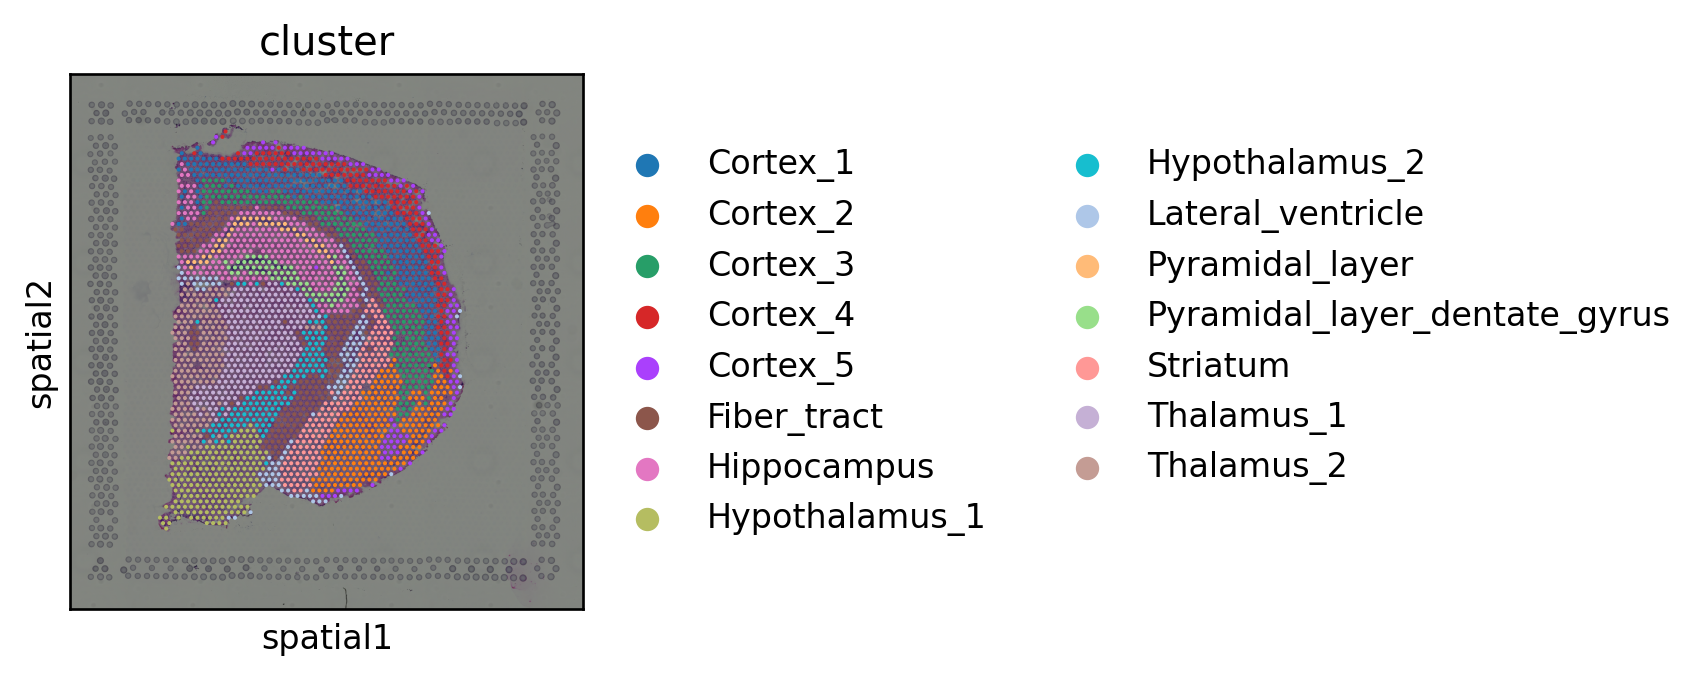

In [30]:
plt.rcParams['figure.figsize'] = (7,6)
# plt.rcParams['figure.dpi'] = 240

sq.pl.spatial_scatter(adata, color="cluster")

### Image feature

Visium datasets contain high-resolution images of the tissue that was used for the gene extraction. Using the function squidpy.im.calculate_image_features() you can calculate image features for each Visium spot and create a obs x features matrix in adata that can then be analyzed together with the obs x gene gene expression matrix.

By extracting image features we are aiming to get both similar and complementary information to the gene expression values. Similar information is for example present in the case of a tissue with two different cell types whose morphology is different. Such cell type information is then contained in both the gene expression values and the tissue image features.

Squidpy contains several feature extractors and a flexible pipeline of calculating features of different scales and sizes. There are several detailed examples of how to use squidpy.im.calculate_image_features(). Extract image features provides a good starting point for learning more.

### extract summary features at different crop sizes and scales

to allow the calculation of multi-scale features and segmentation features. For more information on the summary features, also refer to Extract [summary features](https://squidpy.readthedocs.io/en/latest/notebooks/examples/image/compute_summary_features.html).

In [5]:
# calculate features for different scales (higher value means more context)
for scale in [1.0, 2.0]:
    feature_name = f"features_summary_scale{scale}"
    print(">>>", feature_name)
    sq.im.calculate_image_features(
        adata,
        img.compute(),
        features="summary",
        key_added=feature_name,
        n_jobs=4,
        scale=scale,
    )


# combine features in one dataframe
adata.obsm["features"] = pd.concat(
    [adata.obsm[f] for f in adata.obsm.keys() if "features_summary" in f],
    axis="columns",
)
# make sure that we have no duplicated feature names in the combined table
adata.obsm["features"].columns = ad.utils.make_index_unique(
    adata.obsm["features"].columns
)

>>> features_summary_scale1.0


  0%|          | 0/2688 [00:00<?, ?/s]

>>> features_summary_scale2.0


  0%|          | 0/2688 [00:00<?, ?/s]

In [6]:
for i, key in enumerate(adata.obsm.keys()):
    print(i, key)

0 X_pca
1 X_umap
2 spatial
3 features_summary_scale1.0
4 features_summary_scale2.0
5 features


### extracted image features to compute a new cluster annotation

We can use the extracted image features to compute a new cluster annotation. This could be useful to gain insights in similarities across spots based on image morphology.

In [ ]:
# helper function returning a clustering
def cluster_features(features: pd.DataFrame, like=None) -> pd.Series:
    """
    Calculate leiden clustering of features.
    Specify filter of features using `like`.
    """
    # filter features
    if like is not None:
        features = features.filter(like=like)
    # create temporary adata to calculate the clustering
    adata = ad.AnnData(features)
    # important - feature values are not scaled, so need to scale them before PCA
    sc.pp.scale(adata)
    # calculate leiden clustering
    sc.pp.pca(adata, n_comps=min(10, features.shape[1] - 1))
    sc.pp.neighbors(adata)
    sc.tl.leiden(adata)

    return adata.obs["leiden"]


In [8]:
# calculate feature clusters
adata.obs["features_cluster"] = cluster_features(adata.obsm["features"], like="summary")

/tmp/ipykernel_62282/785858177.py:18: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


In [9]:
for i, key in enumerate(adata.obsm.keys()):
    print(i, key)

0 X_pca
1 X_umap
2 spatial
3 features_summary_scale1.0
4 features_summary_scale2.0
5 features


In [21]:
dfc = adata.obs['cluster']
print(type(dfc), dfc.shape)
dfc.head(6)

<class 'pandas.Series'> (2688,)


AAACAAGTATCTCCCA-1          Cortex_2
AAACAATCTACTAGCA-1          Cortex_5
AAACACCAATAACTGC-1        Thalamus_2
AAACAGAGCGACTCCT-1          Cortex_5
AAACCGGGTAGGTACC-1        Thalamus_2
AAACCGTTCGTCCAGG-1    Hypothalamus_2
Name: cluster, dtype: category
Categories (15, str): ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', ..., 'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']

### There are 257 clusters for Cortex 2

In [38]:
df2 = dfc[dfc=='Cortex_2']
print(df2.shape)
df2.head(3)

(257,)


AAACAAGTATCTCCCA-1    Cortex_2
AAATAGGGTGCTATTG-1    Cortex_2
AACACACGCTCGCCGC-1    Cortex_2
Name: cluster, dtype: category
Categories (15, str): ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', ..., 'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']

In [23]:
adata.obsm.__dict__

{'_axis': 0,
 '_parent': AnnData object with n_obs × n_vars = 2688 × 18078
     obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'features_cluster'
     var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'features_cluster_colors'
     obsm: 'X_pca', 'X_umap', 'spatial', 'features_summary_scale1.0', 'features_summary_scale2.0', 'features'
     varm: 'PCs'
     obsp: 

In [22]:
df = adata.X
print(df.shape)
df

(2688, 18078)


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 15411927 stored elements and shape (2688, 18078)>

Plotting PCA for 'n_genes_by_counts' with dimensions (0, 1)
Plotting PCA for 'log1p_n_genes_by_counts' with dimensions (2, 3)
Plotting PCA for 'total_counts' with dimensions (0, 1)
Plotting PCA for 'log1p_total_counts' with dimensions (2, 3)


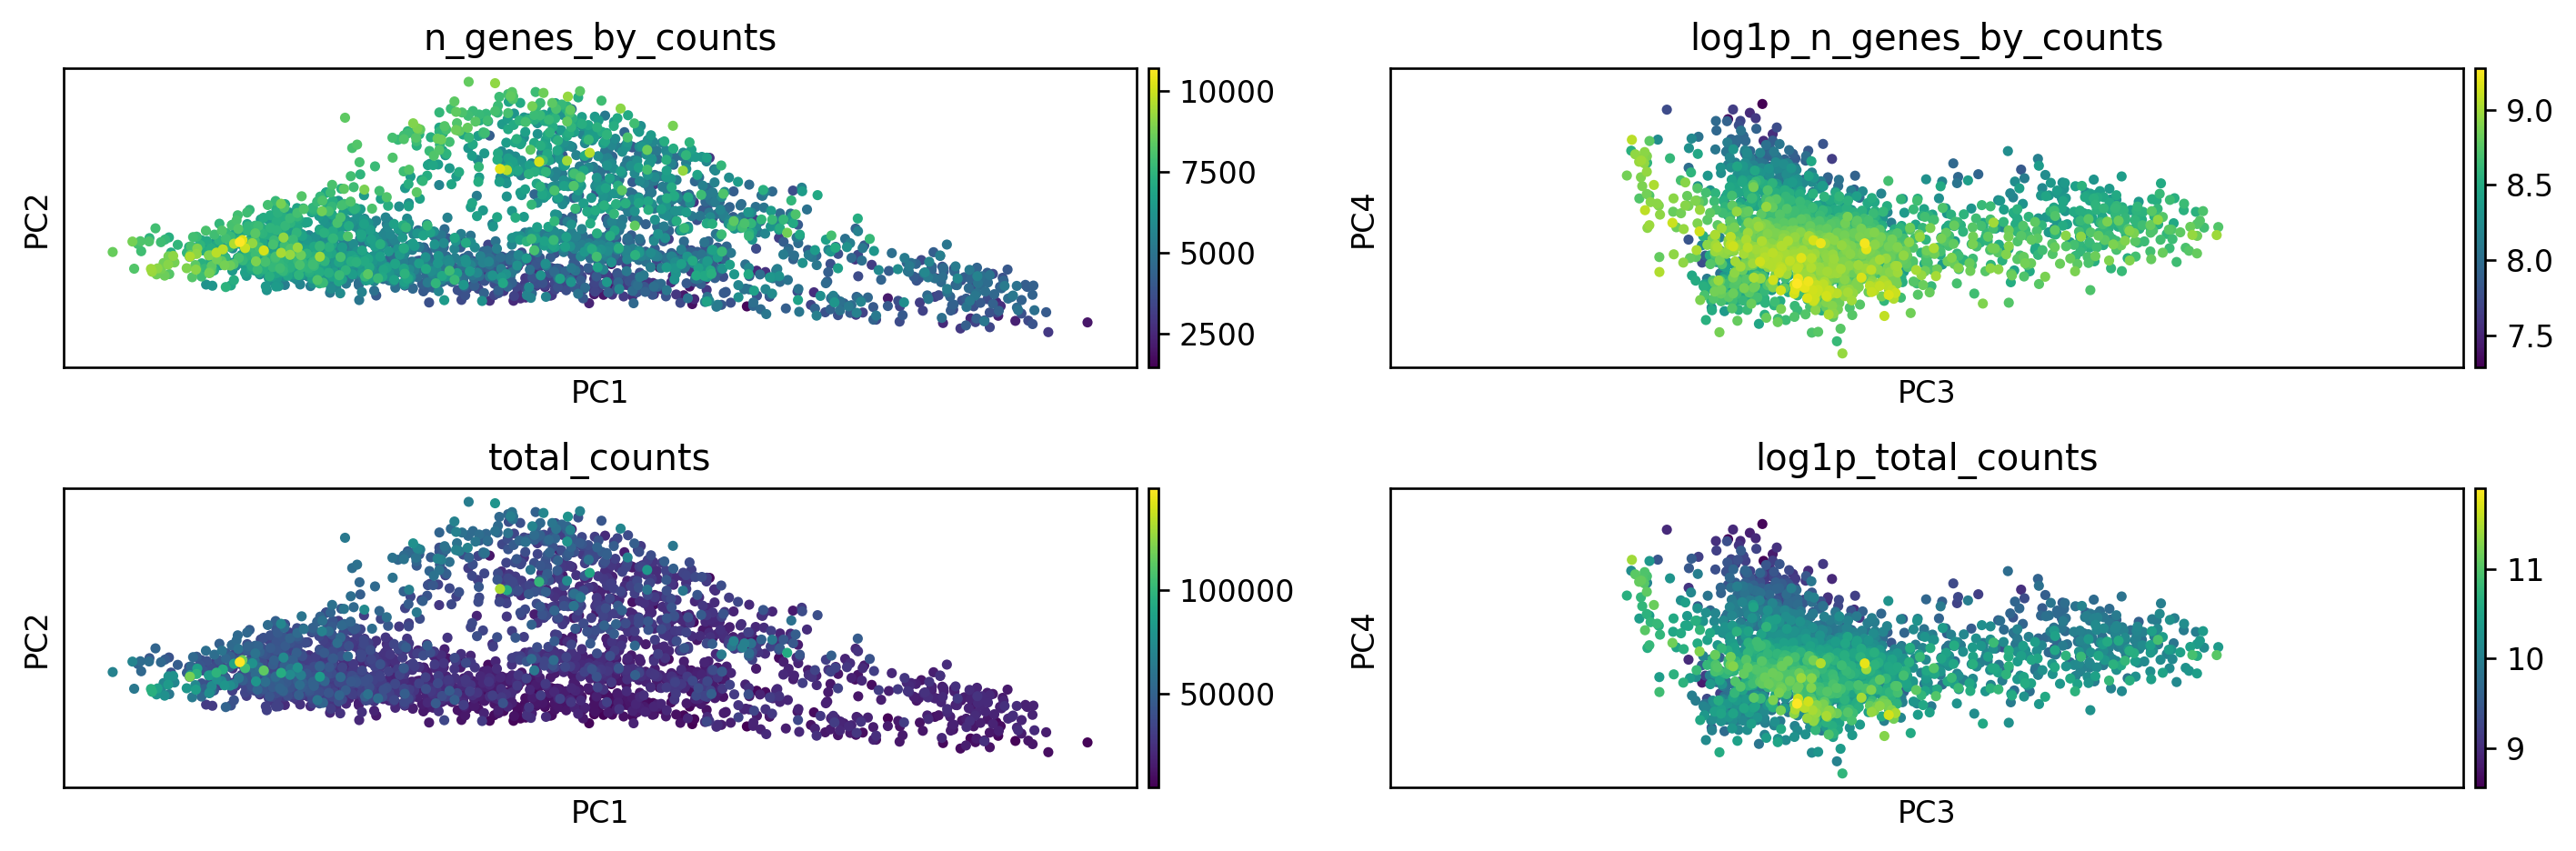

In [39]:
# obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'features_cluster'
# var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     
fig, axes = plt.subplots(2, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, color, dimensions in zip(axes.flat, ["n_genes_by_counts", "log1p_n_genes_by_counts", "total_counts", "log1p_total_counts"], [(0, 1), (2, 3), (0, 1), (2, 3)]):
    sc.pl.pca(adata, color=color, dimensions=dimensions, ax=ax, show=False)
    print(f"Plotting PCA for '{color}' with dimensions {dimensions}")

plt.tight_layout()

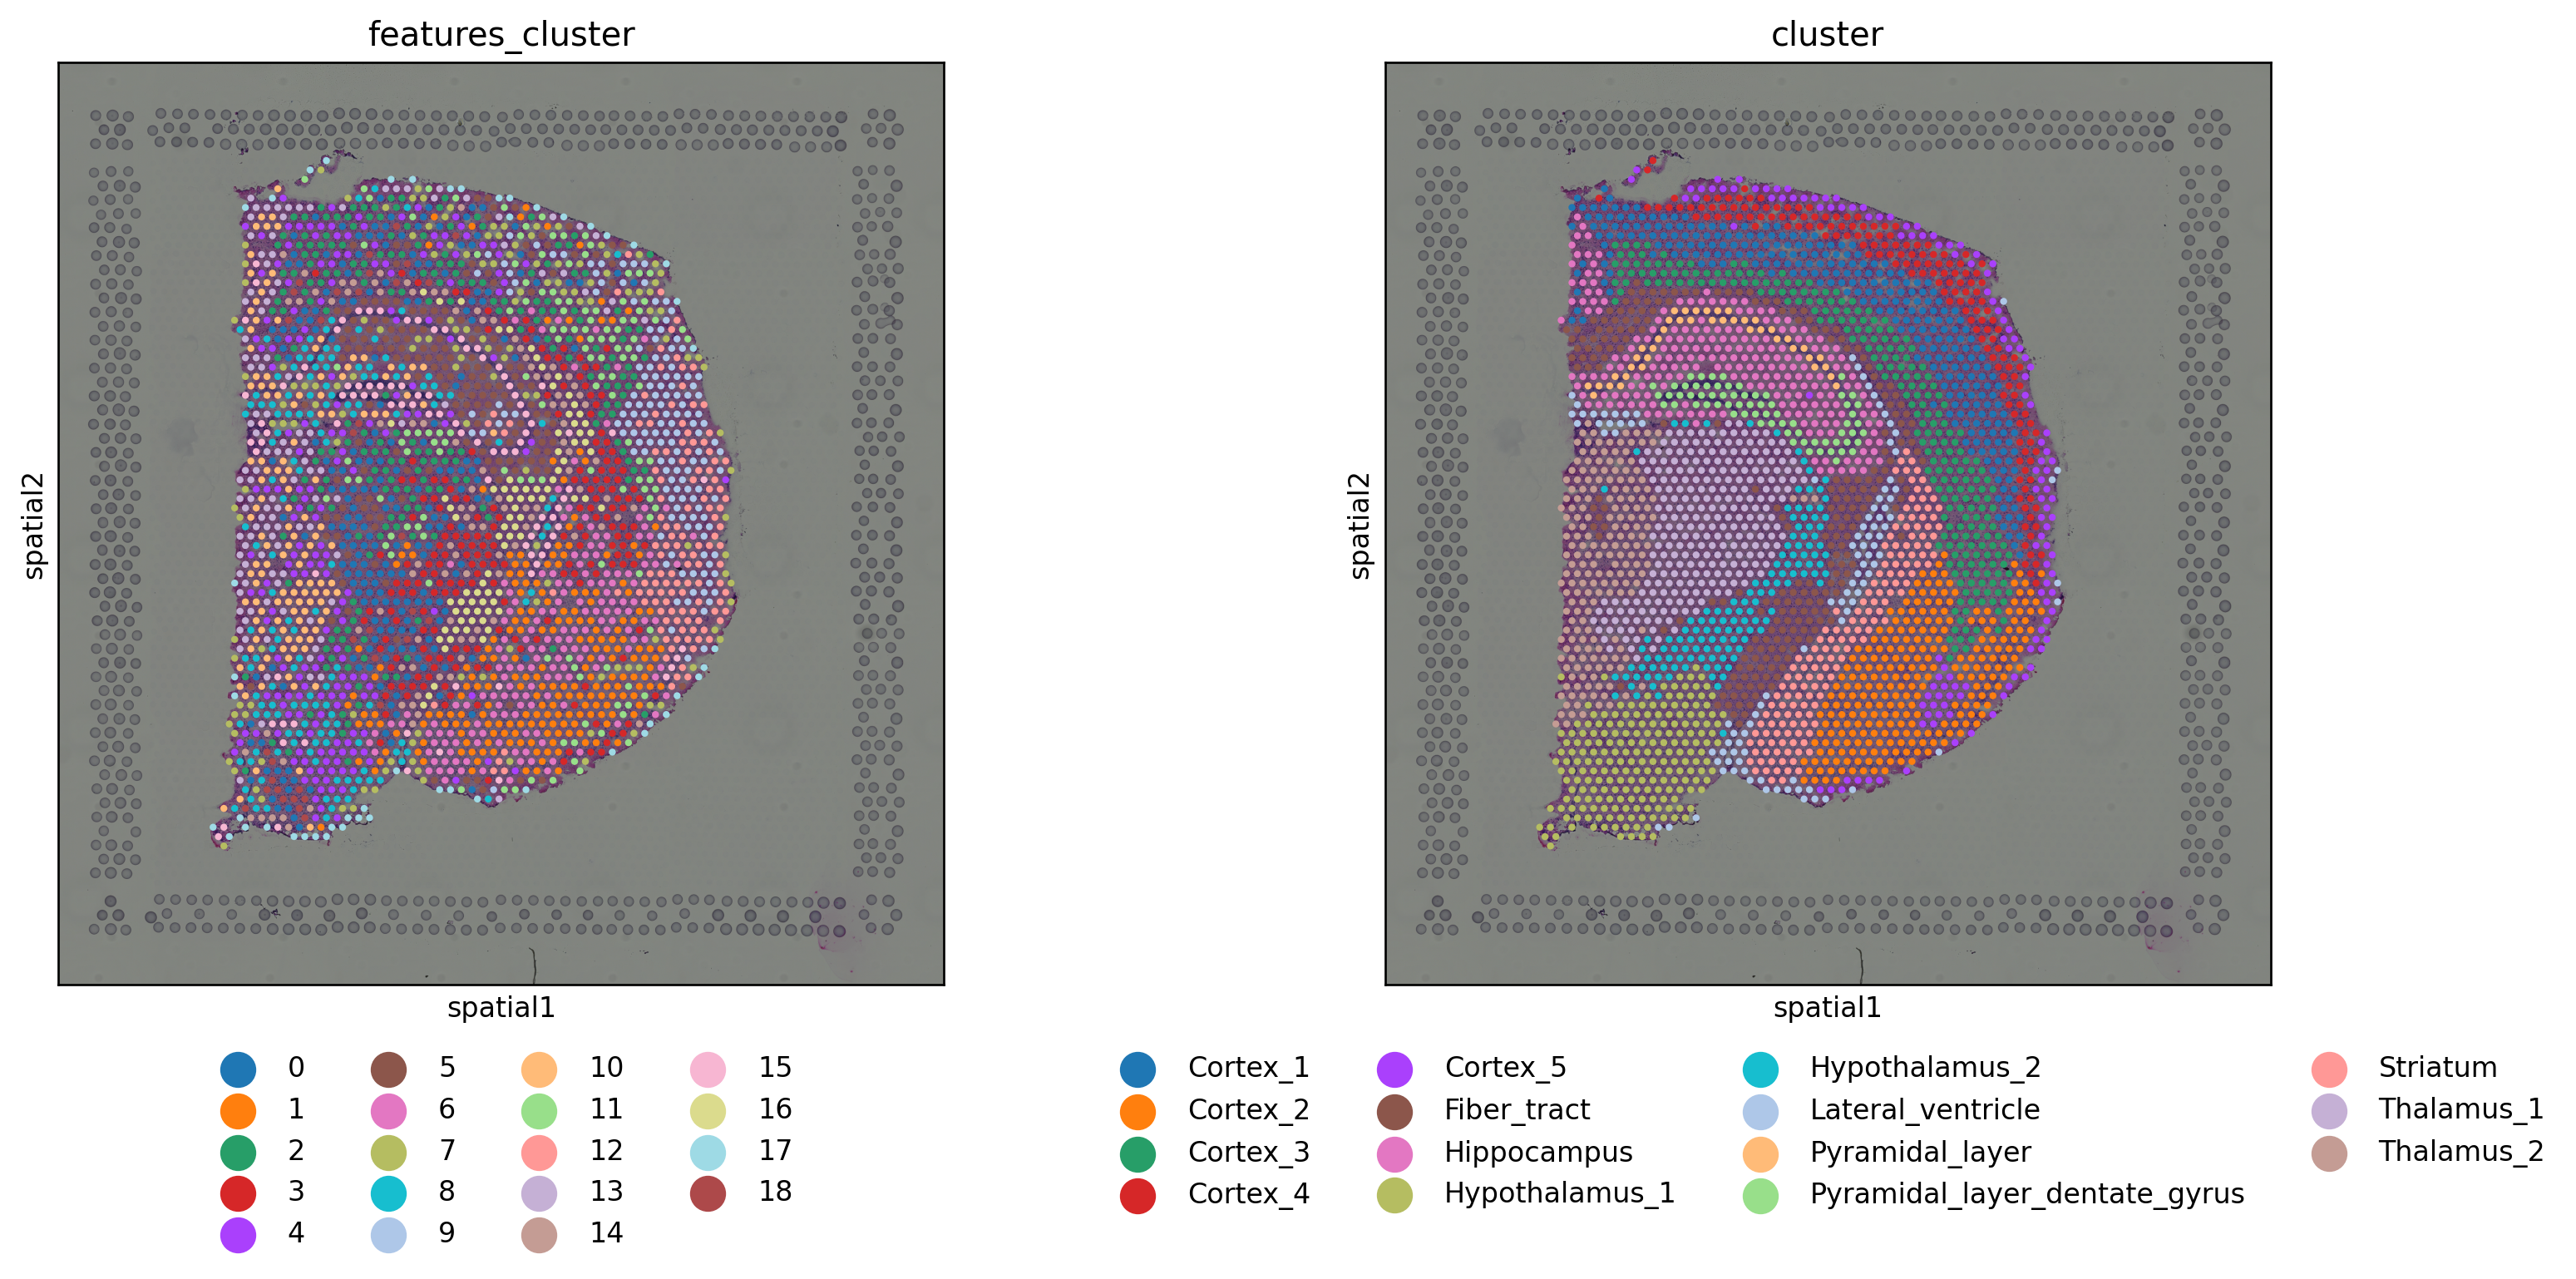

In [36]:
# compare feature and gene clusters
# sq.pl.spatial_scatter(adata, color=["features_cluster", "cluster"])

axs = sq.pl.spatial_scatter(
    adata,
    color=["features_cluster", "cluster"],
    return_ax=True,
)
axs = [axs] if not isinstance(axs, (list, tuple)) else axs

for ax in axs:
    leg = ax.get_legend()
    if leg is None:
        continue
    handles = leg.legend_handles          # .legendHandles on matplotlib < 3.7
    labels = [t.get_text() for t in leg.get_texts()]
    leg.remove()
    ax.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, -0.05),
        ncol=4, frameon=False, markerscale=2,
    )

Comparing gene and feature clusters, we notice that in some regions, they look very similar, like the cluster Fiber_tract, or clusters around the Hippocampus seems to be roughly recapitulated by the clusters in image feature space. In others, the feature clusters look different, like in the cortex, where the gene clusters show the layered structure of the cortex, and the features clusters rather seem to show different regions of the cortex.

This is only a simple, comparative analysis of the image features, note that you could also use the image features to e.g. compute a common image and gene clustering by computing a shared neighbors graph (for instance on concatenated PCAs on both feature spaces).

In [17]:
arr_spatial = adata.obsm['spatial']
arr_spatial

array([[8230, 7237],
       [4170, 1611],
       [2519, 8315],
       ...,
       [3276, 8435],
       [3069, 6639],
       [4720, 2090]], shape=(2688, 2))

In [18]:
dff = adata.obsm['features']
print(dff.shape)
dff.iloc[:3, :6]

(2688, 30)


,summary_ch-0_quantile-0.9,summary_ch-0_quantile-0.5,summary_ch-0_quantile-0.1,summary_ch-0_mean,summary_ch-0_std,summary_ch-1_quantile-0.9
AAACAAGTATCTCCCA-1,132.0,111.0,77.0,107.571140,21.767668,102.0
AAACAATCTACTAGCA-1,140.0,111.0,80.0,109.815175,25.047208,87.0
AAACACCAATAACTGC-1,132.0,116.0,89.0,112.421285,19.088559,109.0
